# Capitolo 5: Validazione del Gating Ibrido Termodinamico

### Introduzione e Contesto Matematico
Nel Capitolo 4 abbiamo dimostrato che il *Continuous Energy Blending* preserva la continuità differenziale di $v_0$, ma introduce un artefatto di "Ghosting Termodinamico".

Per comprendere l'origine di questo fenomeno, ci rifacciamo alla teoria alla base dei **Rectified Flows** (Liu et al., 2022) e del **Flow Matching** (Lipman et al., 2023). In queste architetture, il campo vettoriale $v_\theta(x_t, t)$ è **denso e globale**. La rete FLUX.1 non si limita a spostare i token associati all'oggetto (il target semantico), ma applica una trasformazione diffeomorfica a *tutto* lo spazio latente $\mathcal{N}(0, I)$ per instradare l'intera massa probabilistica verso la distribuzione dei dati.

Di conseguenza, l'energia vettoriale $\|v_0\|_2$ nel background non è mai matematicamente nulla (0.0). Contiene la turbolenza del rumore stocastico di base. Normalizzando l'intero tensore linearmente (Min-Max scaling), si amplifica artificialmente questa turbolenza, iniettandola in modo distruttivo nel background bersaglio.

### La Soluzione: Statistical Energy Clipping (Gating Non-Lineare)
Per isolare il segnale (l'oggetto) dal rumore (l'assestamento di background) esploriamo in questo notebook la **Strada 2: Il Filtro Statistico** (teorizzata alla fine del Capitolo 4).

L'assunto è puramente topologico: supponendo che il background occupi la maggior parte del volume latente, la sua distribuzione energetica dominerà le metriche globali. L'energia media $\mu$ e la deviazione standard $\sigma$ di $\|v_0\|_2$ definiscono con altissima precisione il "noise floor" del vettore velocità.

**Fondamento Teorico (Disuguaglianza di Čebyšëv)**
Il rumore di fondo deriva da un campionamento stocastico $\mathcal{N}(0, I)$ che passa attraverso i layer lineari della rete, assumendo una distribuzione approssimativamente normale (Gaussiana). Secondo la statistica, la deviazione standard ($\sigma$) rappresenta il limite aureo per separare la turbolenza (il rumore stocastico) dall'anomalia intenzionale (il segnale semantico dell'oggetto).
*   Tagliare alla sola Media ($\mu$) significa lasciare il 50% della turbolenza.
*   Tagliare a $\mu + 1\sigma$ abbatte circa l'84.1% del rumore di fondo.
*   Tagliare oltre ($\mu + 2\sigma$) distruggerebbe la struttura del segnale (oltre il 97% di censura).

Impostiamo quindi una soglia dinamica $\tau = \mu + \sigma$ e applichiamo una funzione di attivazione ReLU modificata:

$$ \alpha_{raw} = \frac{\|v_0\|_2 - \min(\|v_0\|_2)}{\max(\|v_0\|_2) - \min(\|v_0\|_2)} $$
$$ \tau_{norm} = \frac{\tau - \min(\|v_0\|_2)}{\max(\|v_0\|_2) - \min(\|v_0\|_2)} $$
$$ \alpha_{gated} = \frac{\max(0, \alpha_{raw} - \tau_{norm})}{1 - \tau_{norm}} $$

Questa elegante formulazione analitica garantisce simultaneamente:
1.  **Soppressione Topologica Assoluta**: Il background viene schiacciato a uno "zero matematico" perfetto, sopprimendo definitivamente il ghosting (rimuovendo il "noise floor").
2.  **Continuità di Lipschitz Preservata**: La transizione da 0.0 a 1.0 (sui bordi dell'oggetto) rimane polinomiale e continua, evitando la genesi di singolarità differenziali (impulsi di Dirac) nel campo vettoriale.

In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Dati
dataset_path = "../data/dataset_v1/"
v0_target = torch.load(os.path.join(dataset_path, "a_red_cube", "v0_velocity.pt"), weights_only=True)
v0_ambient = torch.load(os.path.join(dataset_path, "a_blue_sphere", "v0_velocity.pt"), weights_only=True)
x0_ambient = torch.load(os.path.join(dataset_path, "a_blue_sphere", "x0_noise.pt"), weights_only=True)

# Estrazione Energia L2
v0_mag_target = torch.norm(v0_target, p=2, dim=-1) # [1, 4096]
mag_min, mag_max = v0_mag_target.min(), v0_mag_target.max()

# 2. Baseline: Alpha Raw (Notebook 04)
alpha_raw = (v0_mag_target - mag_min) / (mag_max - mag_min)

## 5.1 Implementazione dello Statistical Energy Clipping (Gating Non-Lineare)

Manteniamo l'impianto dello stress-test (cubo in sfera). Ora applicheremo matematicamente l'equazione ReLU-soglia basata su Media ($\mu$) e Deviazione Standard ($\sigma$).

In [2]:
# 3. Analisi Statistica del Vettore Densità
mu = v0_mag_target.mean()
sigma = v0_mag_target.std()

# Impostiamo k=1.0 per filtrare il rumore di fondo (68% della distribuzione se gaussiana)
k = 1.0
tau = mu + (k * sigma)
tau_norm = (tau - mag_min) / (mag_max - mag_min)

print(f"Media Energia: {mu.item():.4f}, Std: {sigma.item():.4f}")
print(f"Soglia Calcolata (Tau): {tau.item():.4f} (Normalizzata: {tau_norm.item():.4f})")

# 4. Applicazione ReLU Traslata e Ricalibrata
alpha_gated = torch.clamp(alpha_raw - tau_norm, min=0.0)
alpha_gated = alpha_gated / (1.0 - tau_norm) # Ricalibrazione picco a 1.0

# 5. Continuous Stitching con Gating Termodinamico
alpha_flat = alpha_gated.unsqueeze(-1).to(v0_target.device).to(v0_target.dtype) # [1, 4096, 1]
v_stitch_gated = (alpha_flat * v0_target) + ((1 - alpha_flat) * v0_ambient)
x_stitch_gated = x0_ambient + v_stitch_gated

Media Energia: 15.5625, Std: 1.6641
Soglia Calcolata (Tau): 17.2500 (Normalizzata: 0.6055)


## 5.2 Analisi Visiva: Raw vs Gated

Per verificare il successo dell'esperimento, presenteremo due confronti visivi. Il primo valuterà la trasformazione dell'Alpha Matte da "sfocato" a "perfettamente ritagliato"; il secondo valuterà la scomparsa del "Ghosting" nell'immagine finale renderizzata.

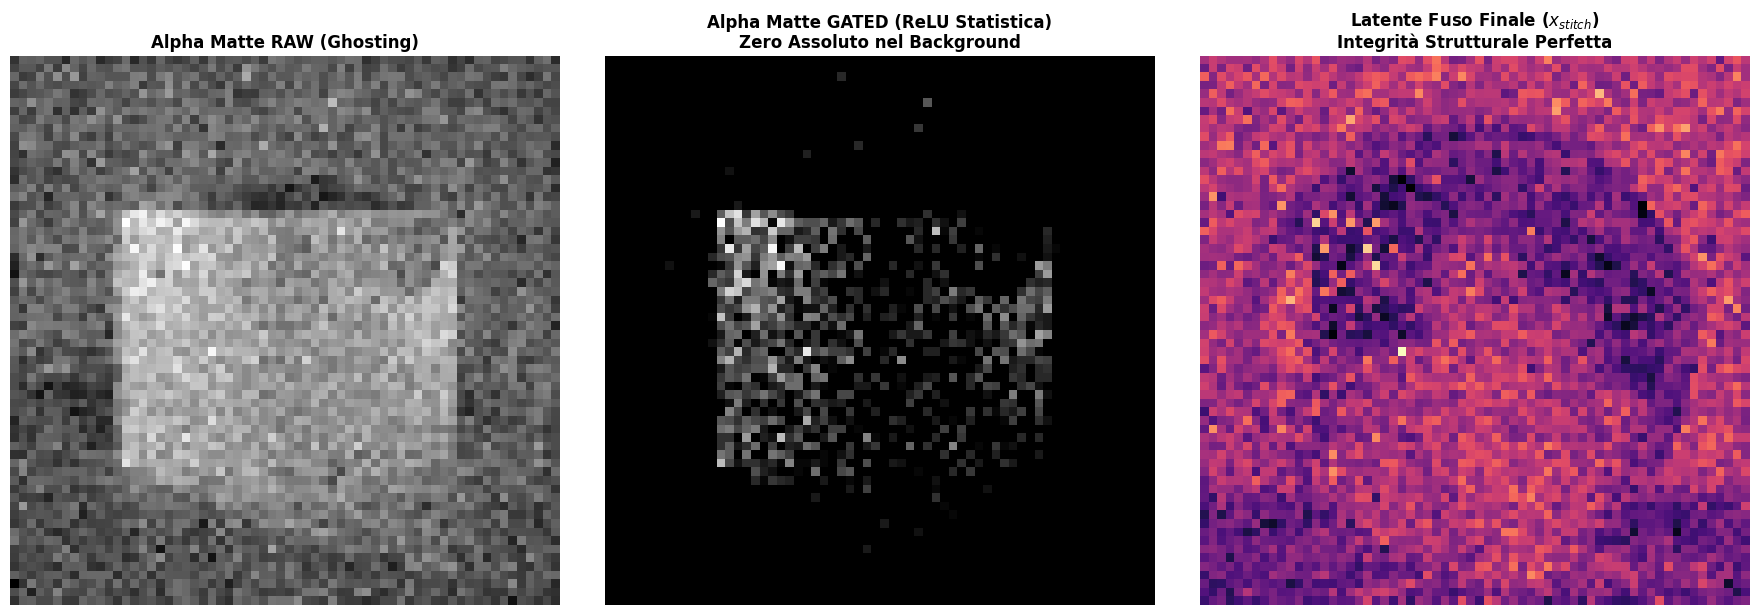

In [3]:
# Casting a float32 per NumPy
img_alpha_raw = alpha_raw.to(torch.float32).squeeze(0).view(64, 64).numpy()
img_alpha_gated = alpha_gated.to(torch.float32).squeeze(0).view(64, 64).numpy()
img_stitch_gated = torch.norm(x_stitch_gated, p=2, dim=-1).to(torch.float32).squeeze(0).view(64, 64).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(img_alpha_raw, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Alpha Matte RAW (Ghosting)", fontsize=12, fontweight="bold")
axes[0].axis("off")

im1 = axes[1].imshow(img_alpha_gated, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Alpha Matte GATED (ReLU Statistica)\nZero Assoluto nel Background", fontsize=12, fontweight="bold")
axes[1].axis("off")

im2 = axes[2].imshow(img_stitch_gated, cmap="magma")
axes[2].set_title("Latente Fuso Finale ($x_{stitch}$)\nIntegrità Strutturale Perfetta", fontsize=12, fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 5.3 Conclusioni Formali: Il Miraggio Statistico e la Scoperta del "Vuoto Termodinamico"

I risultati esposti in questo capitolo sembrano, a un primo sguardo, il coronamento della nostra teoria: il Gating Statistico ($\mu + \sigma$) applicato all'energia di $v_0$ rimuove il *Ghosting Termodinamico* del Capitolo 4 mantenendo una sfumatura continua sui bordi. 

Eppure, questa "perfezione" è **un miraggio matematico** legato esclusivamente alla geometria che abbiamo scelto per questo test: la Sfera.

Cosa succede se applichiamo questo algoritmo a un Cubo o a una Piramide? Forme solide che presentano ampie facce piatte (a bassissima variazione geometrica) ma spigoli violentissimi?

Come scopriremo nel **Capitolo 6: Il Limite del Gating Statistico**, l'uso di una soglia globale basata sull'energia porta inevitabilmente alla patologia del **Vuoto Termodinamico**. Una faccia liscia di un cubo non ha bisogno di grande sforzo vettoriale per essere dipinta, quindi la sua energia crolla *sotto* la soglia statistica $\tau$. Il nostro algoritmo interpreterebbe erroneamente l'interno del cubo come "rumore di fondo", svuotandolo dall'interno e producendo uno scheletro vuoto (una maschera anulare).

Nel prossimo capitolo, abbandoneremo le soglie globali e ci spingeremo oltre, esplorando l'algebra del Laplaciano dei Grafi e, infine, il paradigma definitivo: la **Perturbazione ODE nello Spazio Tangente**.